# Electric-machine loss model verification (McDonald, AIAA 2015-1676)

Plan 005 replaces the default electric-machine losses with the parametric
"rubber motor" of R. A. McDonald, *Modeling of Electric Motor Driven Propellers
for Conceptual Aircraft Design*, AIAA 2015-1676 (53rd AIAA Aerospace Sciences
Meeting). The loss buildup (Larminie and Lowry) is

$$P_L = C_0 + C_1\,\omega + C_2\,\omega^3 + C_3\,Q^2 \qquad (1)$$

with coefficients fixed by the speed $\hat\omega$, torque $\hat Q$ and value
$\hat\eta$ of peak efficiency and a parasite loss ratio $k_0 \in [0, 1]$:

$$C_0 = \frac{k_0\,\hat\omega \hat Q}{6}\frac{1-\hat\eta}{\hat\eta},\quad
C_1 = -\frac{3 C_0}{2\hat\omega} + \frac{\hat Q (1-\hat\eta)}{4\hat\eta},\quad
C_2 = \frac{C_0}{2\hat\omega^3} + \frac{\hat Q (1-\hat\eta)}{4\hat\eta\,\hat\omega^2},\quad
C_3 = \frac{\hat\omega (1-\hat\eta)}{2\hat Q\,\hat\eta} \qquad (2)$$

Ratings follow from ratios on the peak point (eq. 4):
$Q_{rated} = k_Q \hat Q$, $P_{rated} = k_P \hat\omega \hat Q$,
$\omega_{limit} = k_\omega \hat\omega$.

`McDonaldMotorLossModel` keeps the machine interface
`evaluate(speed_rad_s, torque_Nm, voltage_V)` unchanged and is now the default for
`Motor` and `Generator` ($\hat\omega$ = 400 rad/s, $\hat Q$ = 200 Nm,
$\hat\eta$ = 0.96, $k_0$ = 0.5). `SimpleMotorLossModel` remains available and is
verified in `powertrain_verification.ipynb`.

```powershell
uv sync --group notebooks
uv run jupyter lab notebooks/tier1_powertrain_components
```

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import casadi as cas
import matplotlib.pyplot as plt

from aircraft_closure.powertrain.components.generator import Generator
from aircraft_closure.powertrain.components.motor import (McDonaldMotorLossModel, Motor, SimpleMotorLossModel,
                                                          rubber_machine)
from examples.series_hybrid_point import solve_topology_point

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


def efficiency(model, speed_rad_s, torque_Nm):
    power_shaft_W = speed_rad_s * torque_Nm
    return power_shaft_W / (power_shaft_W + model.evaluate(speed_rad_s, torque_Nm, 800))


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

## 1. Coefficients and the peak-efficiency identities

At $(\hat\omega, \hat Q)$ the losses sum to $\hat\omega\hat Q(1-\hat\eta)/\hat\eta$,
so $\eta = \hat\eta$ exactly, and the efficiency gradient vanishes there (that is
how eqs. 2 were derived). $C_1$ simplifies to
$\hat Q(1-\hat\eta)(1-k_0)/(4\hat\eta) \ge 0$, so every coefficient is
non-negative on $k_0 \in [0, 1]$.

In [2]:
model = McDonaldMotorLossModel(speed_peak_efficiency_rad_s=500.0, torque_peak_efficiency_Nm=300.0,
                               efficiency_peak=0.95, parasite_loss_ratio=0.5)
c = model.coefficients()
print(c)
loss_ratio = 0.05 / 0.95
check("eq. 2: C0 = k0 w Q (1 - eta) / (6 eta)", close(c.constant_W, 0.5 * 500 * 300 * loss_ratio / 6))
check("eq. 2: C1 = Q (1 - eta)(1 - k0) / (4 eta)", close(c.linear_W_s_rad, 300 * loss_ratio * 0.5 / 4))
check("eq. 2: C2 = C0 / (2 w^3) + Q (1 - eta) / (4 eta w^2)",
      close(c.cubic_W_s3_rad3, c.constant_W / (2 * 500**3) + 300 * loss_ratio / (4 * 500**2)))
check("eq. 2: C3 = w (1 - eta) / (2 Q eta)", close(c.torque_W_Nm2, 500 * loss_ratio / (2 * 300)))
check("identity: efficiency at the peak point equals eta_hat", close(efficiency(model, 500.0, 300.0), 0.95))
h = 1e-3
gradient = ((efficiency(model, 500 + h, 300) - efficiency(model, 500 - h, 300)) / (2 * h),
            (efficiency(model, 500, 300 + h) - efficiency(model, 500, 300 - h)) / (2 * h))
print(f"efficiency gradient at the peak: {gradient}")
check("identity: efficiency gradient vanishes at the peak", max(abs(g) for g in gradient) < 1e-9)
check("identity: the peak is a maximum (all neighbours lower)",
      all(efficiency(model, 500 * (1 + ds), 300 * (1 + dq)) < 0.95
          for ds in (-0.05, 0, 0.05) for dq in (-0.05, 0, 0.05) if ds or dq))
valid = [McDonaldMotorLossModel(parasite_loss_ratio=k0).coefficients() for k0 in np.linspace(0, 1, 21)]
check("domain: all coefficients non-negative for k0 in [0, 1]",
      all(min(v.constant_W, v.linear_W_s_rad, v.cubic_W_s3_rad3, v.torque_W_Nm2) >= 0 for v in valid))
check("limit: k0 = 0 removes the constant loss", McDonaldMotorLossModel(parasite_loss_ratio=0).coefficients().constant_W == 0)
check("limit: eta_hat = 1 gives a lossless machine",
      McDonaldMotorLossModel(efficiency_peak=1.0).evaluate(700, 350, 800) == 0)

McDonaldLossCoefficients(constant_W=657.8947368421059, linear_W_s_rad=1.9736842105263177, cubic_W_s3_rad3=1.8421052631578968e-05, torque_W_Nm2=0.043859649122807064)
PASS  eq. 2: C0 = k0 w Q (1 - eta) / (6 eta)
PASS  eq. 2: C1 = Q (1 - eta)(1 - k0) / (4 eta)
PASS  eq. 2: C2 = C0 / (2 w^3) + Q (1 - eta) / (4 eta w^2)
PASS  eq. 2: C3 = w (1 - eta) / (2 Q eta)
PASS  identity: efficiency at the peak point equals eta_hat
efficiency gradient at the peak: (-5.551115123125783e-14, -5.551115123125783e-14)
PASS  identity: efficiency gradient vanishes at the peak
PASS  identity: the peak is a maximum (all neighbours lower)
PASS  domain: all coefficients non-negative for k0 in [0, 1]
PASS  limit: k0 = 0 removes the constant loss
PASS  limit: eta_hat = 1 gives a lossless machine


## 2. Reference case: the paper's Figure 1 rubber motor

Figure 1 of the paper shows the seven-parameter model with $\hat\eta$ = 95 %,
$k_0$ = 0.5 and $k_Q = k_P = k_\omega = 2$, on axes normalized by the peak point,
with contours at 25, 50, 75, 80, 85, 90, 93, 94 and 94.9 %. The same instance is
reproduced here through `rubber_machine`, inside the max-torque, max-power and
max-speed limits.

PASS  eq. 4: rated torque = kQ Q_hat
PASS  eq. 4: rated power = kP w_hat Q_hat
PASS  eq. 4: speed limit = kw w_hat


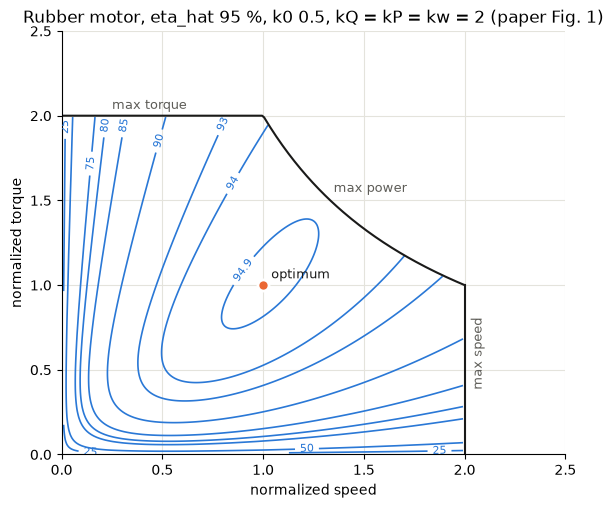

grid maximum 0.95000 at speed 1.001, torque 1.001
PASS  Fig. 1: grid maximum is the optimum (1, 1) within grid spacing
PASS  Fig. 1: maximum efficiency 95 %
PASS  Fig. 1: both envelope corners are below the peak and above 90 %
PASS  Fig. 1: torque-corner loss share follows C3 Q^2 dominance (rated corner above max-speed corner)
rated corner 0.9383, max-speed corner 0.9231


In [3]:
figure1 = rubber_machine(Motor, speed_peak_efficiency_rad_s=1.0, torque_peak_efficiency_Nm=1.0, efficiency_peak=0.95,
                         parasite_loss_ratio=0.5, torque_ratio=2, power_ratio=2, speed_ratio=2)
check("eq. 4: rated torque = kQ Q_hat", figure1.max_torque_Nm == 2.0)
check("eq. 4: rated power = kP w_hat Q_hat", figure1.power_rated_W == 2.0)
check("eq. 4: speed limit = kw w_hat", figure1.max_speed_rad_s == 2.0)

speed, torque = np.meshgrid(np.linspace(0.01, 2.5, 300), np.linspace(0.01, 2.5, 300))
eta = efficiency(figure1.loss_model, speed, torque)
inside = (torque <= 2) & (speed <= 2) & (speed * torque <= 2)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
levels = [0.25, 0.50, 0.75, 0.80, 0.85, 0.90, 0.93, 0.94, 0.949]
contours = ax.contour(speed, torque, np.where(inside, eta, np.nan), levels=levels, colors=blue, linewidths=1.2)
ax.clabel(contours, fmt=lambda v: f"{100 * v:g}", fontsize=8)
envelope_speed = np.linspace(0, 2, 200)
ax.plot(envelope_speed, np.minimum(2.0, 2.0 / np.maximum(envelope_speed, 1e-9)), color=ink, lw=1.5)
ax.plot([2, 2], [0, 1], color=ink, lw=1.5)
ax.plot([1], [1], "o", color=orange, ms=8, mec="white", mew=2)
ax.text(1.04, 1.04, "optimum", color=ink, fontsize=9)
ax.text(0.25, 2.04, "max torque", color=ink_muted, fontsize=9)
ax.text(1.35, 1.55, "max power", color=ink_muted, fontsize=9)
ax.text(2.03, 0.4, "max speed", color=ink_muted, fontsize=9, rotation=90)
ax.set(xlabel="normalized speed", ylabel="normalized torque", xlim=(0, 2.5), ylim=(0, 2.5),
       title="Rubber motor, eta_hat 95 %, k0 0.5, kQ = kP = kw = 2 (paper Fig. 1)")
plt.show()

eta_inside = np.where(inside, eta, 0)
peak_index = np.unravel_index(np.argmax(eta_inside), eta.shape)
print(f"grid maximum {eta_inside[peak_index]:.5f} at speed {speed[peak_index]:.3f}, torque {torque[peak_index]:.3f}")
check("Fig. 1: grid maximum is the optimum (1, 1) within grid spacing",
      abs(speed[peak_index] - 1) < 0.01 and abs(torque[peak_index] - 1) < 0.01)
check("Fig. 1: maximum efficiency 95 %", close(float(eta_inside.max()), 0.95, rel=1e-4))
# Corner values are model outputs recorded for reference; the paper's contour
# positions are not machine-readable from the PDF, so no figure match is claimed.
check("Fig. 1: both envelope corners are below the peak and above 90 %",
      all(0.90 < efficiency(figure1.loss_model, w, q) < 0.95 for w, q in ((1.0, 2.0), (2.0, 1.0))))
check("Fig. 1: torque-corner loss share follows C3 Q^2 dominance (rated corner above max-speed corner)",
      efficiency(figure1.loss_model, 1.0, 2.0) > efficiency(figure1.loss_model, 2.0, 1.0))
print(f"rated corner {efficiency(figure1.loss_model, 1.0, 2.0):.4f}, "
      f"max-speed corner {efficiency(figure1.loss_model, 2.0, 1.0):.4f}")

## 3. Rubber scaling and physical trends

Scaling $\hat Q$ by $s$ at fixed $\hat\omega$ and $\hat\eta$ scales every
coefficient so that losses at $(\omega, sQ)$ are exactly $s$ times those at
$(\omega, Q)$: a bigger machine of the same technology has the same efficiency
map in normalized coordinates. Efficiency falls at light torque (constant and
speed losses dominate) and at high speed ($C_2\omega^3$).

PASS  scaling: 4x peak torque gives exactly 4x losses at 4x torque
PASS  scaling: normalized efficiency map unchanged by rubber scaling
PASS  trend: efficiency drops at light torque
PASS  trend: efficiency drops at high speed
PASS  identity: k0 does not change losses at the peak speed
PASS  trend: larger k0 lowers low-speed efficiency


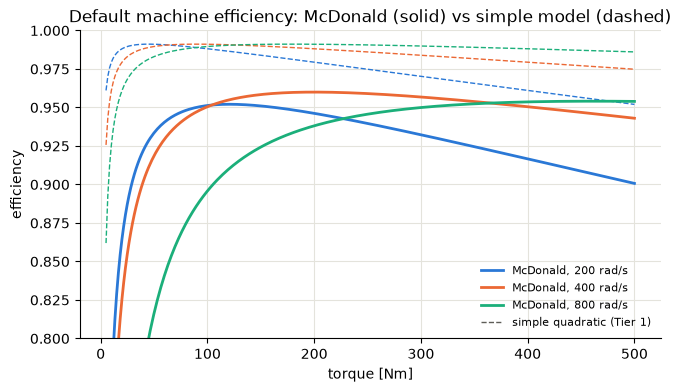

In [4]:
base = McDonaldMotorLossModel(400.0, 200.0)
scaled = McDonaldMotorLossModel(400.0, 800.0)
check("scaling: 4x peak torque gives exactly 4x losses at 4x torque",
      all(close(scaled.evaluate(w, 4 * q, 800), 4 * base.evaluate(w, q, 800)) for w, q in ((100, 50), (400, 200), (900, 450))))
check("scaling: normalized efficiency map unchanged by rubber scaling",
      close(efficiency(scaled, 300, 600), efficiency(base, 300, 150)))
check("trend: efficiency drops at light torque", efficiency(base, 400, 20) < efficiency(base, 400, 200))
check("trend: efficiency drops at high speed", efficiency(base, 1000, 200) < efficiency(base, 400, 200))
# At w = w_hat the speed-dependent terms total 2 Q_hat w_hat (1 - eta)/(4 eta)
# for any k0, so the parasite ratio only matters away from the peak speed.
check("identity: k0 does not change losses at the peak speed",
      close(McDonaldMotorLossModel(parasite_loss_ratio=0.9).evaluate(400, 40, 800),
            McDonaldMotorLossModel(parasite_loss_ratio=0.1).evaluate(400, 40, 800)))
check("trend: larger k0 lowers low-speed efficiency",
      efficiency(McDonaldMotorLossModel(parasite_loss_ratio=0.9), 100, 40)
      < efficiency(McDonaldMotorLossModel(parasite_loss_ratio=0.1), 100, 40))

torque_Nm = np.linspace(5, 500, 300)
fig, ax = plt.subplots(figsize=(7.5, 4))
for speed_rad_s, color in ((200, blue), (400, orange), (800, aqua)):
    ax.plot(torque_Nm, efficiency(base, speed_rad_s, torque_Nm), color=color, lw=2, label=f"McDonald, {speed_rad_s} rad/s")
    ax.plot(torque_Nm, efficiency(SimpleMotorLossModel(), speed_rad_s, torque_Nm), color=color, lw=1, ls="--")
ax.plot([], [], color=ink_muted, lw=1, ls="--", label="simple quadratic (Tier 1)")
ax.set(xlabel="torque [Nm]", ylabel="efficiency", ylim=(0.80, 1.0),
       title="Default machine efficiency: McDonald (solid) vs simple model (dashed)")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.show()

## 4. Default machines and the reference hover point

Defaults put the peak at the reference hover operating point (400 rad/s, 200 Nm)
with $\hat\eta$ = 0.96. Motor and generator share the loss function; generator
efficiency is $P_e/P_s = 1 - P_L/(\omega Q)$. $C_0$ is a constant loss present even
at standstill (domain $\omega, Q \ge 0$). The coupled reference point keeps its
rotor shaft power (losses act on the electrical side only) while battery power
and fuel flow rise to cover the more realistic machine losses.

In [5]:
motor, generator = Motor(), Generator()
m = motor.evaluate(400, 200, 800)
g = generator.evaluate(400, 200, 800)
print(f"motor efficiency {m.power_shaft_W / m.power_electric_W:.4f}, generator efficiency "
      f"{g.power_electric_W / g.power_shaft_W:.4f}")
check("default: motor efficiency at the reference point is 0.96", close(m.power_shaft_W / m.power_electric_W, 0.96))
check("default: generator shares the losses", close(g.power_loss_W, m.power_loss_W))
check("default: standstill loss equals C0", close(motor.evaluate(0, 0, 800).power_loss_W,
                                                  motor.loss_model.coefficients().constant_W))
point = solve_topology_point()
print(point)
check("reference point: rotor shaft power unchanged (89.286 kW)", close(point.shaft_power_W, 89285.745, rel=1e-5))
check("reference point: battery power 19.184 kW with McDonald losses", close(point.battery_power_W, 19184.051, rel=1e-5))
check("reference point: fuel flow 0.006207 kg/s with McDonald losses", close(point.fuel_flow_kg_s, 0.0062072, rel=1e-4))
quad = solve_topology_point(count_rotors=4)
check("reference point: rubber-scaled generator makes 4-rotor fuel flow exactly 4x",
      close(quad.fuel_flow_kg_s, 4 * point.fuel_flow_kg_s, rel=1e-6))

motor efficiency 0.9600, generator efficiency 0.9583
PASS  default: motor efficiency at the reference point is 0.96
PASS  default: generator shares the losses
PASS  default: standstill loss equals C0


TopologyPointResult(thrust_N=5000.000000017691, shaft_power_W=89285.74504736398, battery_power_W=19184.050699507883, fuel_flow_kg_s=0.006207175261399817, bus_power_residual_W=-1.680891728028655e-07, rotor_power_residual_W=-9.478244464844465e-07, current_motor_A=120.08055862902874, current_motors_total_A=120.08055862902874, voltage_bus_V=798.7991944137107, max_abs_connection_residual=2.1040591491328087e-10, min_operating_margin=0.07952840157356696, binding_margin_label='motor power_shaft_W')
PASS  reference point: rotor shaft power unchanged (89.286 kW)
PASS  reference point: battery power 19.184 kW with McDonald losses
PASS  reference point: fuel flow 0.006207 kg/s with McDonald losses
PASS  reference point: rubber-scaled generator makes 4-rotor fuel flow exactly 4x


## 5. Symbolic parameters

All four parameters may be Opti variables, so a later sizing problem can scale
the rubber machine. Minimizing the loss at a fixed operating point over $\hat Q$
recovers $\hat Q$ = the operating torque: a machine is most efficient where its
peak sits.

In [6]:
opti = asb.Opti()
torque_peak_Nm = opti.variable(init_guess=120, lower_bound=1)
loss_W = McDonaldMotorLossModel(torque_peak_efficiency_Nm=torque_peak_Nm).evaluate(400, 200, 800)
check("symbolic: loss with a symbolic peak torque is CasADi MX", isinstance(loss_W, cas.MX))
opti.minimize(loss_W / 1e3)
solution = opti.solve(verbose=False)
print(f"optimal peak torque {solution.value(torque_peak_Nm):.4f} Nm")
check("symbolic: loss-minimizing peak torque equals the operating torque",
      close(float(solution.value(torque_peak_Nm)), 200.0, rel=1e-5))

PASS  symbolic: loss with a symbolic peak torque is CasADi MX


optimal peak torque 200.0000 Nm
PASS  symbolic: loss-minimizing peak torque equals the operating torque


## 6. Summary and unit test suite

In [7]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

32 / 32 notebook checks passed


In [8]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 276 tests in 51.626s

OK
